# **Séries Temporais**

# TRANSFORMAÇÃO E DIFERENCIAÇÃO

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15,6

### **Transformação**

Transformar a série que não tenha distribuição normal em uma série com distribuição aproximadamente normal

**AirPassengers: dados clássicos da companhia aérea Box & Jenkins. Totais mensais de passageiros de companhias aéreas internacionais, 1949 a 1960.**
 

In [45]:
# dados = pd.read_csv('AirPassengers.csv', sep=',')
import seaborn as sns
dados = sns.load_dataset("flights")
dados.head()
#Renomeando colunas para consistência, se necessário
dados.columns = ['Year','Month', 'Passengers']

In [46]:
dados

,Year,Month,Passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [47]:
data_string = dados['Year'].astype(str) + '-' + dados['Month'].astype(str)

dados['Date'] = pd.to_datetime(data_string, format='%Y-%b')

# Configurando a nova coluna como o Índice da Série Temporal
dados.set_index('Date', inplace=True)

# 4. Definindo a frequência como Início do Mês (Monthly Start)
dados.index.freq = 'MS'

# 5. Criando a variável AP contendo apenas a Série Temporal
serie = dados['Passengers']

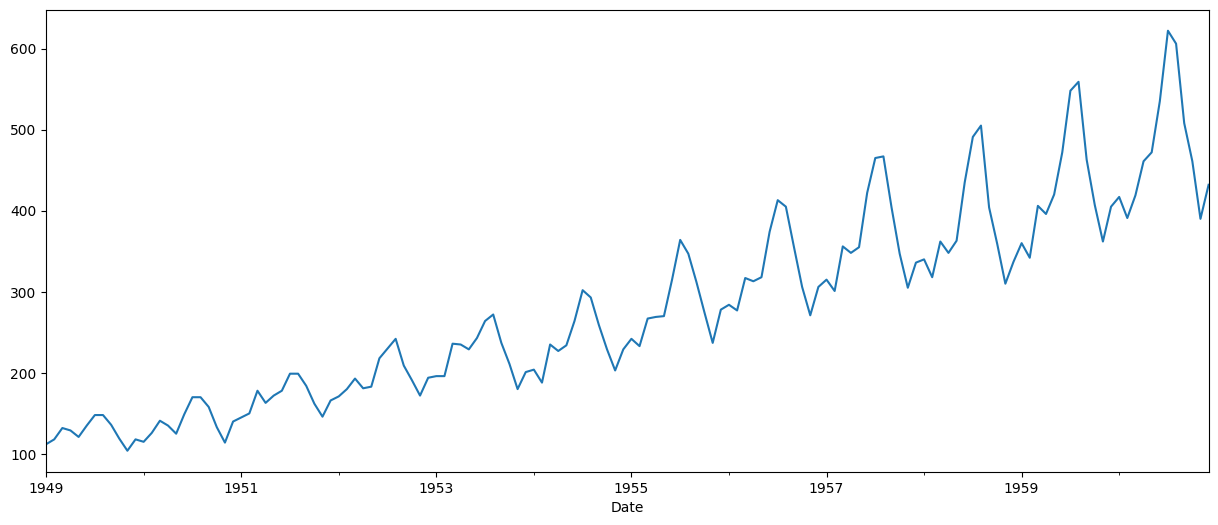

In [48]:
serie.plot()
plt.show()

Tendencia crescente ao longo dos anos e sazonalidade clara, onde de tempos em tempos (regulares) há picos bem marcados. Esses picos começam com uma amplitude pequena e vai aumentando ao passar dos anos.

***Verificando a normalidade dos dados***

In [49]:
import scipy.stats as stats

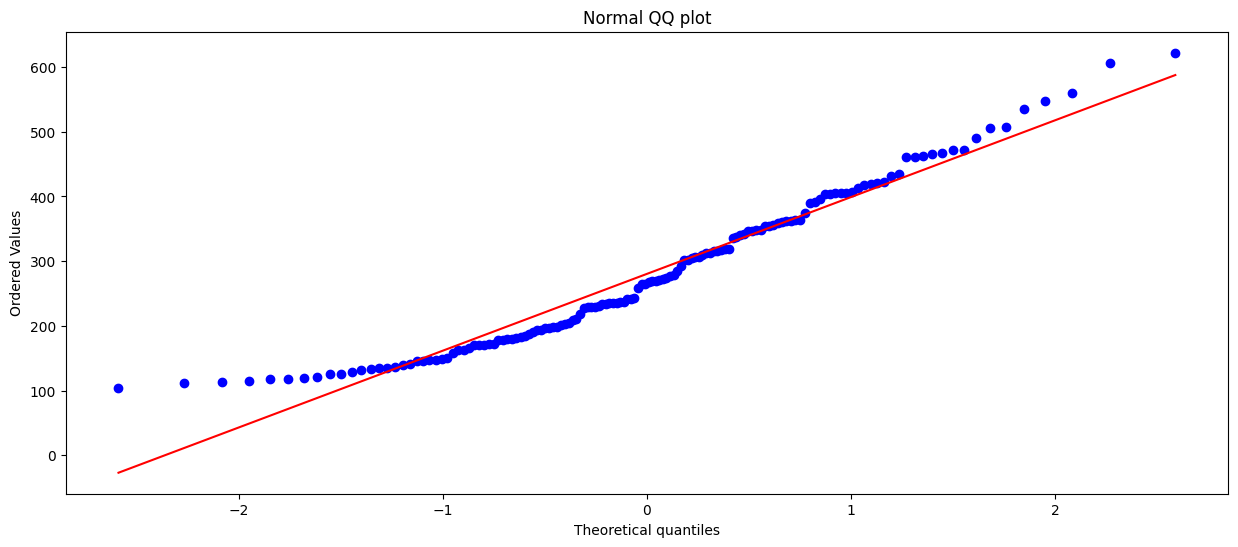

In [50]:
stats.probplot(serie, dist="norm", plot=plt)
plt.title("Normal QQ plot")
plt.show()

Serie aparentemente demonstra problemas de normalidade no começo e um pouco no final, pois é onde ela se distancia da linha.

**Teste Shapiro-Wilk**

CRITÉRIOS:

NÍVEL DE SIGNIFICÂNCIA DE 0,05 ou 5% (MAIS UTILIZADO)

* H0: A série segue uma distribuição aproximadamente normal QUANDO p > 0,05.
* Ha: A série NÃO segue uma distribuição aproximadamente normal QUANDO p < 0,05.

In [51]:
e, p = stats.shapiro(serie)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9519579410552979
p-valor: 6.832739018136635e-05


Como p é menor que 0,05 podemos dizer que a distribuição não é normal.

Para tentarmos resolver esse problema podemos utilizar a transformação logarítmica ou exponencial

### Transformação por log 

Diminui variância e melhora normalidade

Aplica a função logarítmica em todos os dados da série

In [52]:
serie2 = np.log(serie)
serie2

Date
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
                ...   
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Freq: MS, Name: Passengers, Length: 144, dtype: float64

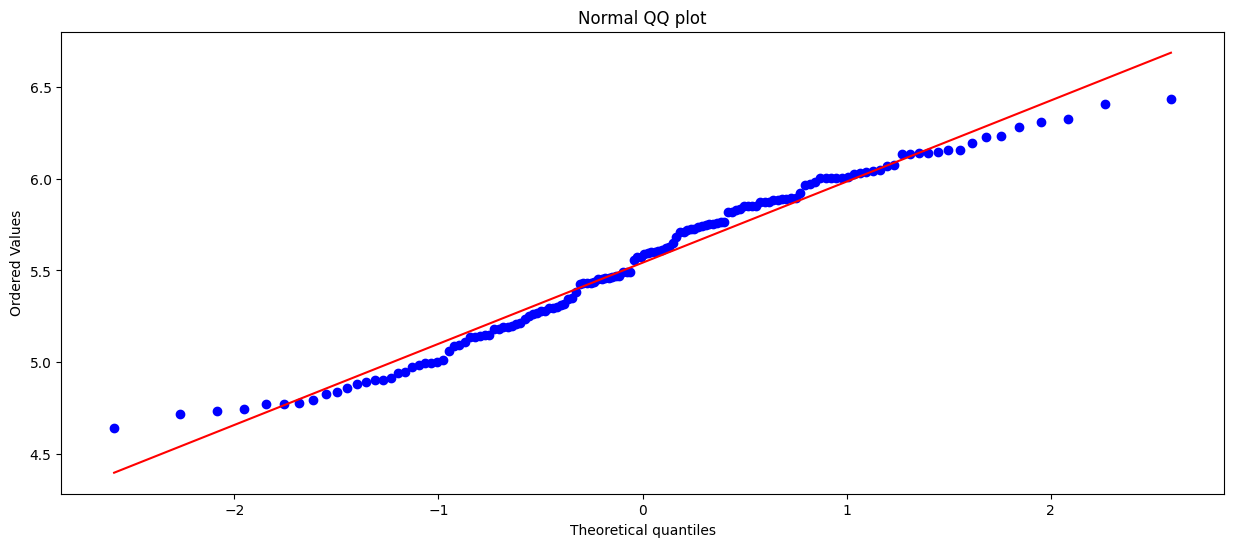

In [53]:
stats.probplot(serie2, dist="norm", plot=plt)
plt.title("Normal QQ plot")
plt.show()

Observa-se que o início da série a uma aproximação com a linha de referencia, porem o fim da série houve um afastamento maior. Há uma possível na normalidade dos dados.

**Teste Shapiro-Wilk**

CRITÉRIOS:

NÍVEL DE SIGNIFICÂNCIA DE 0,05 ou 5% (MAIS UTILIZADO)

* H0: A série segue uma distribuição aproximadamente normal QUANDO p > 0,05.
* Ha: A série NÃO segue uma distribuição aproximadamente normal QUANDO p < 0,05.

In [54]:
e, p = stats.shapiro(serie2)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9732357859611511
p-valor: 0.00637402106076479


Observa-se uma melhoria na normalidade pela proximidade o p-valor com o nivel de significância, porem ainda não temos dados normais

### Transformação por raiz cúbica

Transformação muito utilizada quando a série possui dados com valor zero ou negativos

In [55]:
serie3 = (serie)**(1/3)
serie3

Date
1949-01-01    4.820285
1949-02-01    4.904868
1949-03-01    5.091643
1949-04-01    5.052774
1949-05-01    4.946087
                ...   
1960-08-01    8.462348
1960-09-01    7.979112
1960-10-01    7.725032
1960-11-01    7.306144
1960-12-01    7.559526
Freq: MS, Name: Passengers, Length: 144, dtype: float64

No python sempre que temos o operador de raiz e tivermos números negativos ele fará um tratamento transformando os números em números complexos.

Quando a raiz é quadrada, não existe um numero real que retorne uma raiz negativa (apenas um número complexo), agora se for raiz cubica existiria núneros reais.

Aparece NaN - valor missing

In [56]:
serie_3 = np.sign(serie)*abs(serie)**(1/3)
serie_3

Date
1949-01-01    4.820285
1949-02-01    4.904868
1949-03-01    5.091643
1949-04-01    5.052774
1949-05-01    4.946087
                ...   
1960-08-01    8.462348
1960-09-01    7.979112
1960-10-01    7.725032
1960-11-01    7.306144
1960-12-01    7.559526
Freq: MS, Name: Passengers, Length: 144, dtype: float64

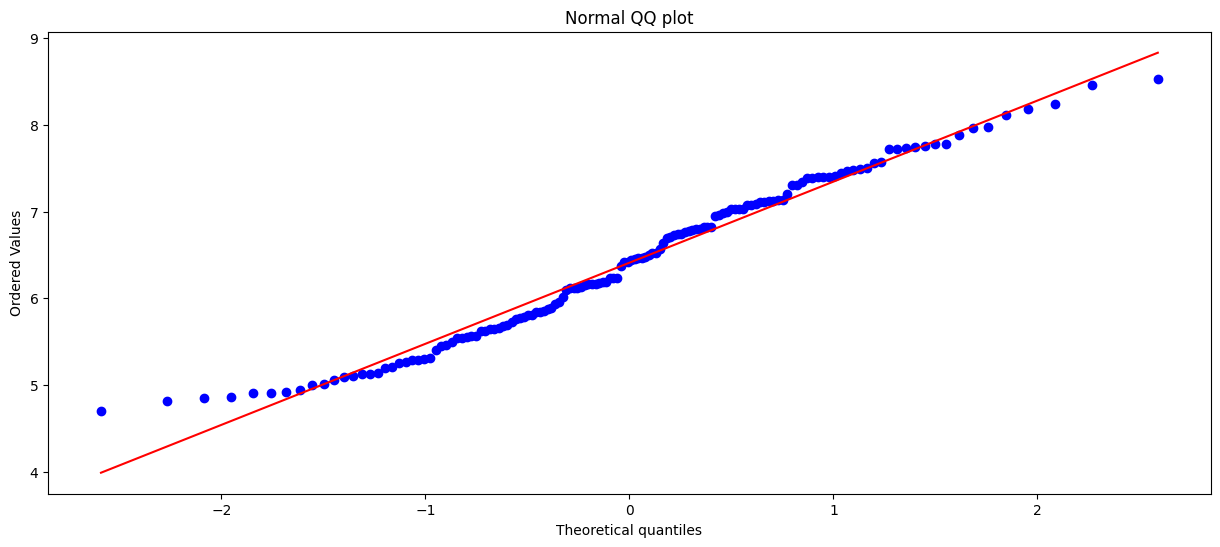

In [57]:
stats.probplot(serie_3, dist="norm", plot=plt)
plt.title("Normal QQ plot")
plt.show()

Ajusta melhor o final da série , porem no inicio ainda existe um afastamento da linha de referencia. Aparentemente melhorou a normalidade da série

**Teste Shapiro-Wilk**

CRITÉRIOS:

NÍVEL DE SIGNIFICÂNCIA DE 0,05 ou 5% (MAIS UTILIZADO)

* H0: A série segue uma distribuição aproximadamente normal QUANDO p > 0,05.
* Ha: A série NÃO segue uma distribuição aproximadamente normal QUANDO p < 0,05.

In [58]:
e, p = stats.shapiro(serie_3)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.974599301815033
p-valor: 0.008835508488118649


Verificando a normalidade dos dados com o histograma

C:\Users\anail\AppData\Local\Temp\ipykernel_31920\4139522692.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(serie); #serie original
c:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


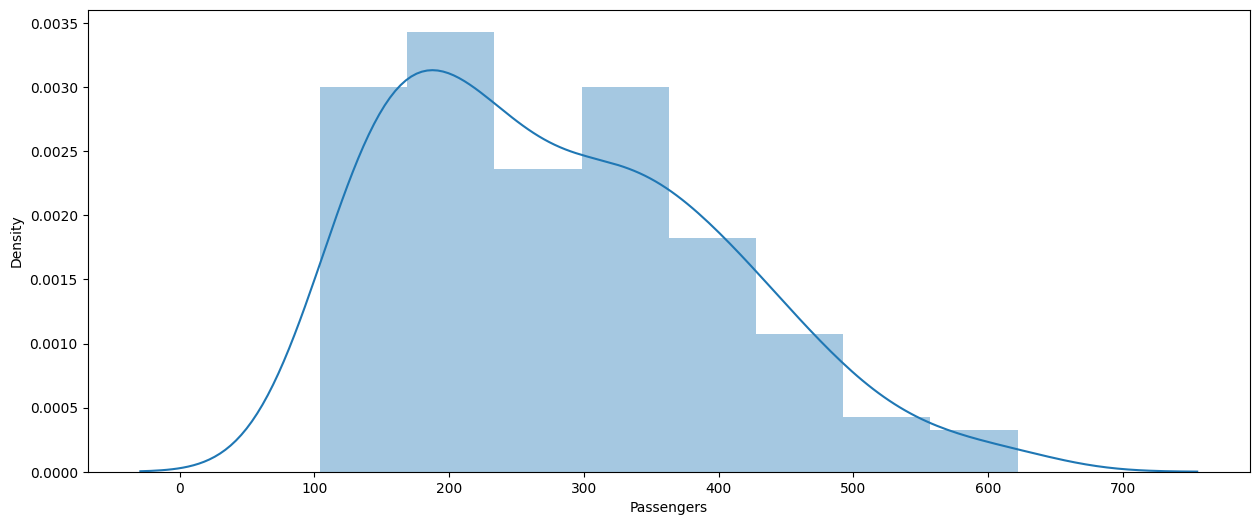

In [59]:

sns.distplot(serie); #serie original

C:\Users\anail\AppData\Local\Temp\ipykernel_31920\442880662.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(serie2); #serie transformada com log
c:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


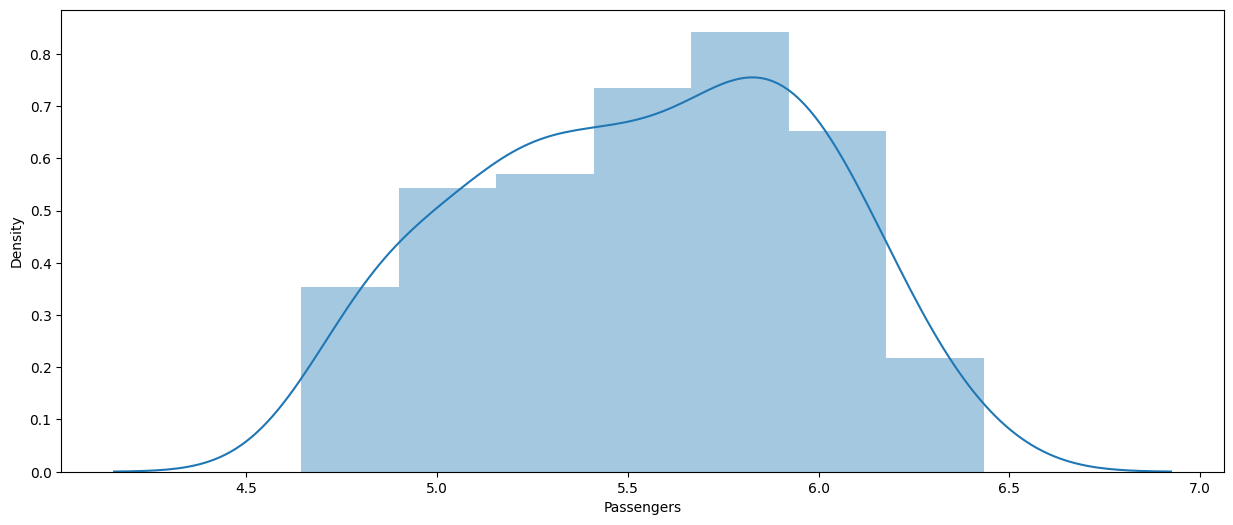

In [60]:
sns.distplot(serie2); #serie transformada com log

C:\Users\anail\AppData\Local\Temp\ipykernel_31920\3840144360.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(serie_3) #serie transformada com a raiz cubica(exponencial)
c:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Passengers', ylabel='Density'>

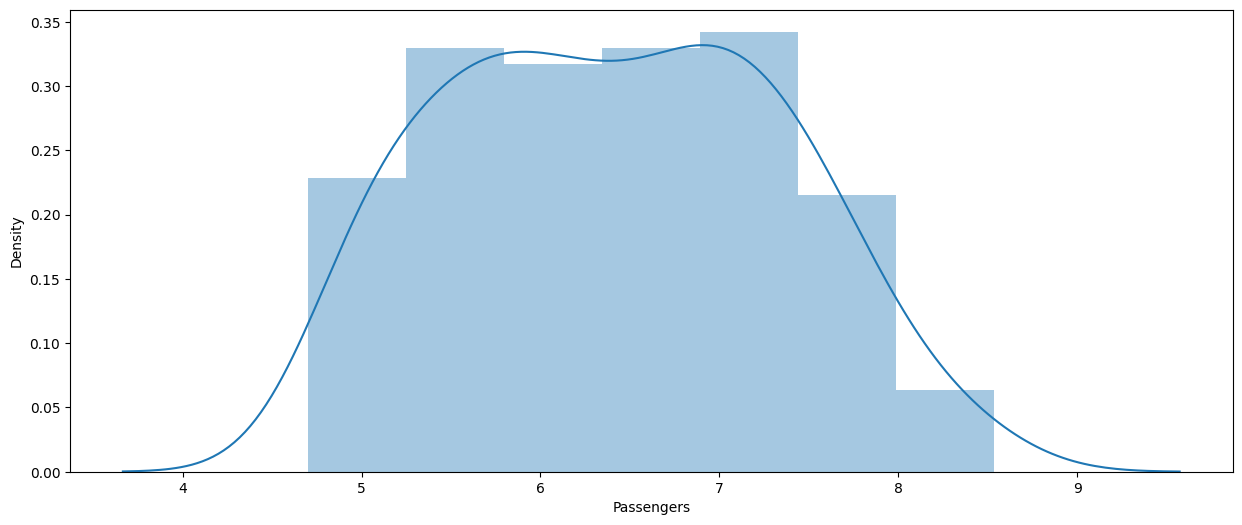

In [61]:
sns.distplot(serie_3) #serie transformada com a raiz cubica(exponencial)

Buscamos o formato de sino, da curva normal.

### **DIFERENCIAÇÃO**

Transformar uma série não estacionária em uma série estacionária 

In [62]:
import statsmodels.tsa.stattools

Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

Ha = não é estacionário: estatística do teste > valor crítico (p-valor < 0,05)

Ho = é estacionário:  estatística do teste < valor crítico  (p-valor > 0,05)

In [63]:
kpss = statsmodels.tsa.stattools.kpss(serie3)
print('Estatítica do teste: {:.4f}'.format(kpss[0]))
print('p_valor: {:.4f}'.format(kpss[1]))
print('Valores Críticos:')
for chave, valor in kpss[3].items():
   print('{}: {:.4f}'.format(chave, valor))

Estatítica do teste: 1.6735
p_valor: 0.0100
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


C:\Users\anail\AppData\Local\Temp\ipykernel_31920\1748613426.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss = statsmodels.tsa.stattools.kpss(serie3)


Como temos a estatística(1.6735) do teste é maior que o valor crítico(0.4630), temos que a série não é estacionária

Teste df (Dickey Fuller)

Ho = não é estacionário: estatística do teste >= valor crítico (p-valor > 0,05)

Ha = é estacionário:  estatística do teste < valor crítico (p-valor < 0,05)

In [64]:
df = statsmodels.tsa.stattools.adfuller(serie3)
print('Estatítica do teste: {:.4f}'.format(df[0]))
print('p_valor: {:.8f}'.format(df[1]))
print('Valores Críticos:')
for chave, valor in df[4].items():
   print('{}: {:.4f}'.format(chave, valor))

Estatítica do teste: -0.8100
p_valor: 0.81615655
Valores Críticos:
1%: -3.4817
5%: -2.8840
10%: -2.5788


Como temos a estatística(-0.8100) do teste é menor que o valor crítico(-2.8840), temos que a série não é estacionária

Fazendo a diferenciação

Lembrando que iremos perder o primeiro valor pois não temos o antecessor para subtrair

In [65]:
serie4 = np.diff(serie3)

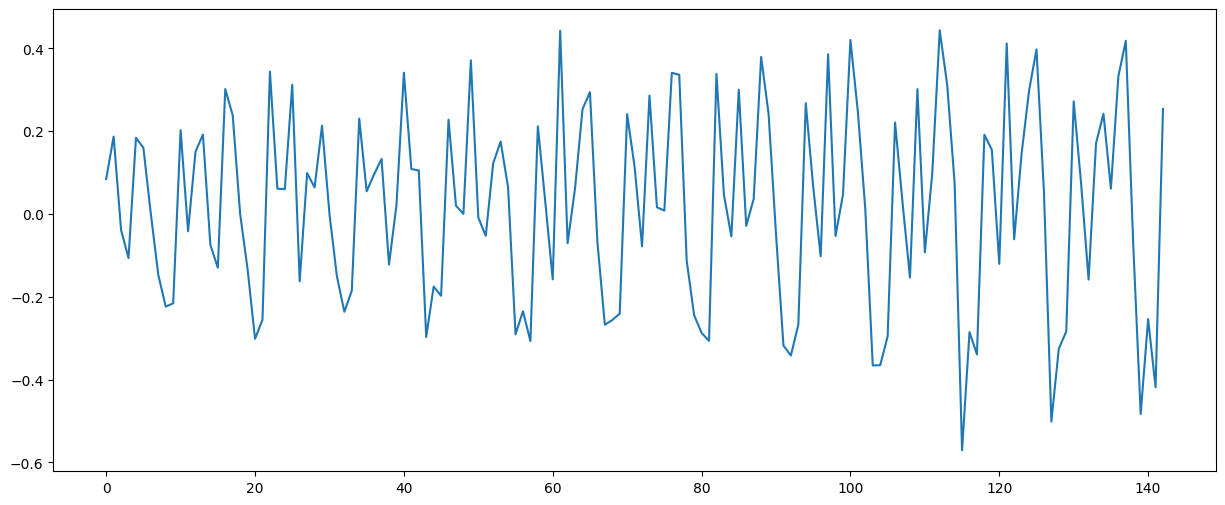

In [66]:
plt.plot(serie4)
plt.show()

In [67]:
serie

Date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: Passengers, Length: 144, dtype: int64

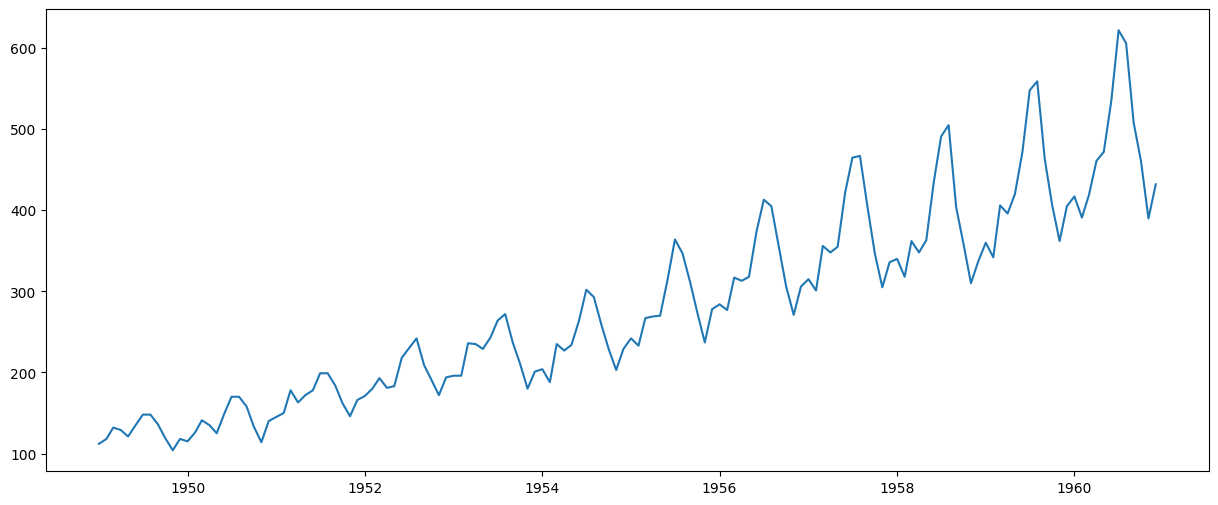

In [68]:
plt.plot(serie)
plt.show()

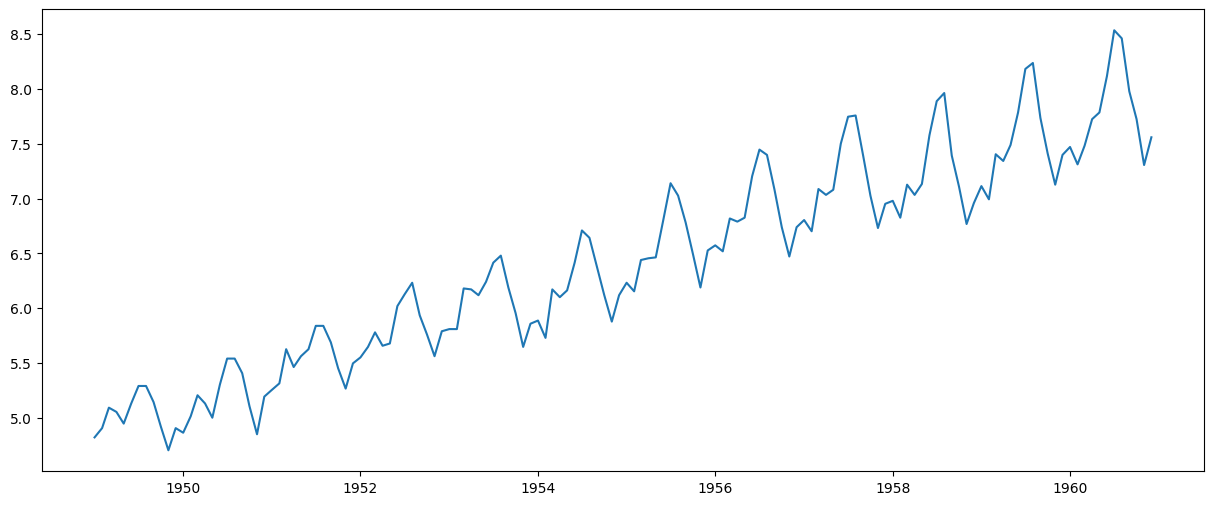

In [69]:
plt.plot(serie3)
plt.show()

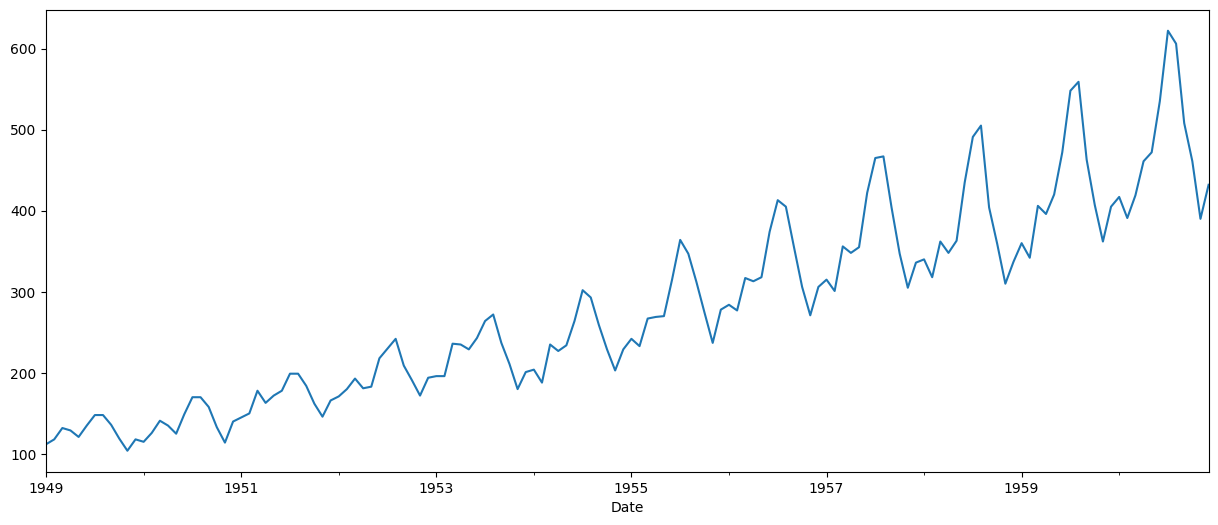

In [70]:
serie.plot()
plt.show()

Desmostrando como é realizada a diferenciação :

Subtração da série por um valor antecessor dela mesma

In [71]:
serie_diff = serie3 - serie3.shift()
#shift -> valor antecessor 

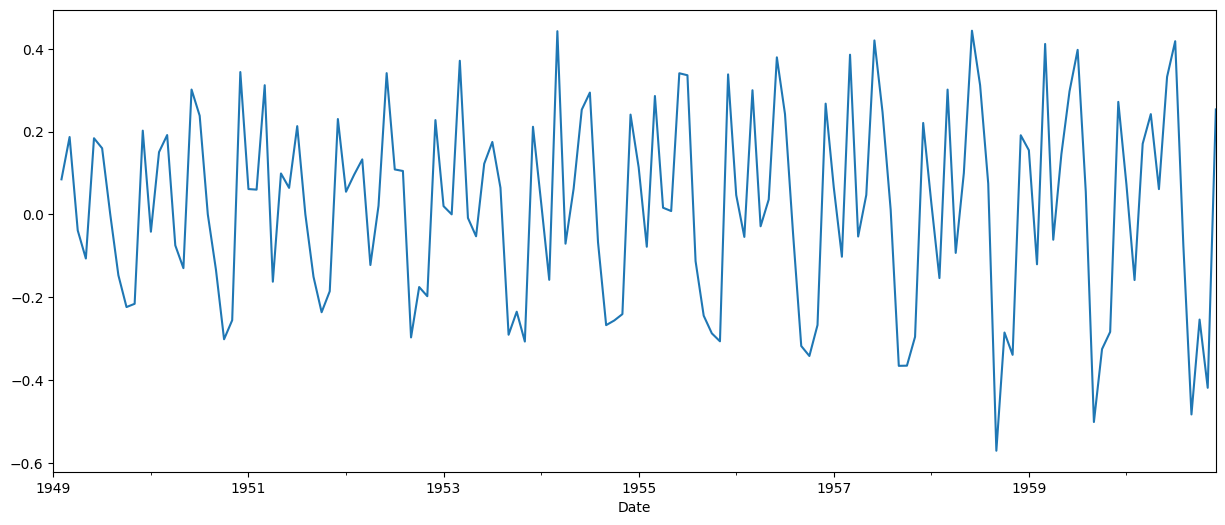

In [72]:
serie_diff.plot()
plt.show()

Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

Ho = não é estacionário: p-valor < 0.05

Ha = é estacionário:  p-valor > 0.05

In [73]:
kpss = statsmodels.tsa.stattools.kpss(serie4)
print('Estatítica do teste: {:.4f}'.format(kpss[0]))
print('p_valor: {:.4f}'.format(kpss[1]))
print('Valores Críticos:')
for chave, valor in kpss[3].items():
   print('{}: {:.4f}'.format(chave, valor))

Estatítica do teste: 0.0266
p_valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


C:\Users\anail\AppData\Local\Temp\ipykernel_31920\3851743177.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss = statsmodels.tsa.stattools.kpss(serie4)


Como a estatística(0.0266) do teste é menor que o valor crítico(0.4630), temos que a série é estacionária

Caso não tivesse chegado a estacionaridade poderíamos realizar a Diferenciação de segunda ordem.


In [74]:
serie5 = np.diff(serie4)

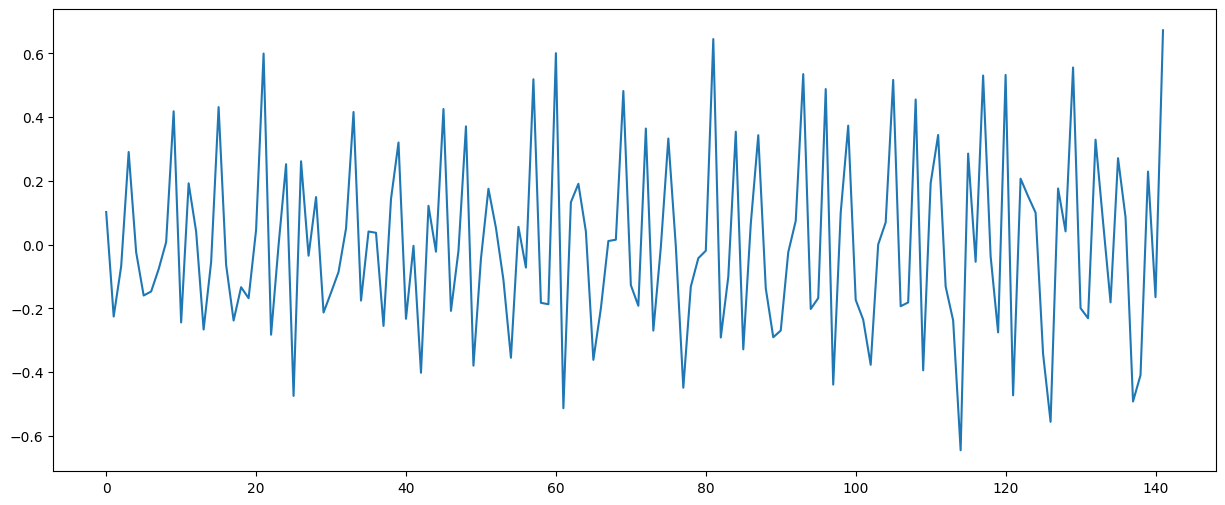

In [75]:
plt.plot(serie5)
plt.show()

In [76]:
kpss = statsmodels.tsa.stattools.kpss(serie5)
print('Estatítica do teste: {:.4f}'.format(kpss[0]))
print('p_valor: {:.4f}'.format(kpss[1]))
print('Valores Críticos:')
for chave, valor in kpss[3].items():
   print('{}: {:.4f}'.format(chave, valor))

Estatítica do teste: 0.0762
p_valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


C:\Users\anail\AppData\Local\Temp\ipykernel_31920\1100002076.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss = statsmodels.tsa.stattools.kpss(serie5)


### REVERSÃO DA TRANSFORMAÇÃO E DIFERENCIAÇÃO

Ao realizarmos a transformação e diferenciação das séries temporais alteramos os valores das séries, logo para fazermos previsões temos que realizar a reversão da trasnformação e diferenciação das séries - queremos fazer previsões na escala original

Transformação por log (Este log é o logaritmo natural(ln), tem base e)

In [77]:
serie

Date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: Passengers, Length: 144, dtype: int64

In [78]:
serie2 = np.log(serie)
serie2

Date
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
                ...   
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Freq: MS, Name: Passengers, Length: 144, dtype: float64

log = logatitimo natural de base e

In [79]:
serie_revertida =  np.e**serie2
serie_revertida

Date
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
              ...  
1960-08-01    606.0
1960-09-01    508.0
1960-10-01    461.0
1960-11-01    390.0
1960-12-01    432.0
Freq: MS, Name: Passengers, Length: 144, dtype: float64

Transformação de logaritmo de base 10

In [80]:
serie2 = np.log10(serie)
serie2

Date
1949-01-01    2.049218
1949-02-01    2.071882
1949-03-01    2.120574
1949-04-01    2.110590
1949-05-01    2.082785
                ...   
1960-08-01    2.782473
1960-09-01    2.705864
1960-10-01    2.663701
1960-11-01    2.591065
1960-12-01    2.635484
Freq: MS, Name: Passengers, Length: 144, dtype: float64

In [81]:
serie_revertida =  10**serie2
serie_revertida

Date
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
              ...  
1960-08-01    606.0
1960-09-01    508.0
1960-10-01    461.0
1960-11-01    390.0
1960-12-01    432.0
Freq: MS, Name: Passengers, Length: 144, dtype: float64

### REVERSÃO DA TRANSFORMAÇÃO POR RAIZ CÚBICA

Transformação por raiz cúbica (quando possui dados com valor zero ou negativos)

In [82]:
serie3 = (serie)**(1/3)
serie3

Date
1949-01-01    4.820285
1949-02-01    4.904868
1949-03-01    5.091643
1949-04-01    5.052774
1949-05-01    4.946087
                ...   
1960-08-01    8.462348
1960-09-01    7.979112
1960-10-01    7.725032
1960-11-01    7.306144
1960-12-01    7.559526
Freq: MS, Name: Passengers, Length: 144, dtype: float64

In [83]:
serie_revertida = serie3**3
serie_revertida

Date
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
              ...  
1960-08-01    606.0
1960-09-01    508.0
1960-10-01    461.0
1960-11-01    390.0
1960-12-01    432.0
Freq: MS, Name: Passengers, Length: 144, dtype: float64

### REVERSÃO DA DIFERENCIAÇÃO

Diferenciação - difereça do valor da serie pelo seu antecessor 

Lembrando que iremos perder o primeiro valor pois não temos o antecessor para subtrair

In [84]:
serie_diferenciada = serie.diff()
serie_diferenciada

Date
1949-01-01     NaN
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Freq: MS, Name: Passengers, Length: 144, dtype: float64

In [85]:
serie_revertida = serie.shift(1) + serie_diferenciada
serie_revertida
#shift(1) -> valor antecessor

Date
1949-01-01      NaN
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
              ...  
1960-08-01    606.0
1960-09-01    508.0
1960-10-01    461.0
1960-11-01    390.0
1960-12-01    432.0
Freq: MS, Name: Passengers, Length: 144, dtype: float64

**Organizando no dataframe**

Fazer a diferenciação dos valores que estão na coluna Passengers e criar uma coluna no Dataframe com o nome: valores_diferenciados

In [86]:
dados['valores_diferenciados'] = dados['Passengers'].diff()
dados

,Year,Month,Passengers,valores_diferenciados
Date,,,,
1949-01-01,1949,Jan,112,NaN
1949-02-01,1949,Feb,118,6.0
1949-03-01,1949,Mar,132,14.0
1949-04-01,1949,Apr,129,-3.0
1949-05-01,1949,May,121,-8.0
...,...,...,...,...
1960-08-01,1960,Aug,606,-16.0
1960-09-01,1960,Sep,508,-98.0
1960-10-01,1960,Oct,461,-47.0


Reverter a diferenciação da coluna valores_diferenciados e criar mais uma coluna com o nome valores_revertidos

In [87]:
dados['valores_revertidos'] = dados['Passengers'].shift(1) + dados['valores_diferenciados']
dados

,Year,Month,Passengers,valores_diferenciados,valores_revertidos
Date,,,,,
1949-01-01,1949,Jan,112,NaN,NaN
1949-02-01,1949,Feb,118,6.0,118.0
1949-03-01,1949,Mar,132,14.0,132.0
1949-04-01,1949,Apr,129,-3.0,129.0
1949-05-01,1949,May,121,-8.0,121.0
...,...,...,...,...,...
1960-08-01,1960,Aug,606,-16.0,606.0
1960-09-01,1960,Sep,508,-98.0,508.0
1960-10-01,1960,Oct,461,-47.0,461.0
